In [3]:

"""Bước 1: đọc bộ dữ liệu sinh viên và xem qua một lượt.

Chú thích trong tệp viết tiếng Việt có dấu, nhưng phần in ra màn hình cố ý
viết không dấu. Cửa sổ lệnh Windows thường không hiện được chữ có dấu.
"""
import pandas as pd

df = pd.read_csv("data/sinh_vien.csv")

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()

# Cột qua mon chỉ có hai giá trị, đếm số lần xuất hiện từng giá trị
print("So sinh vien theo ket qua:")
print(df["qua_mon"].value_counts())
print()

print("Ty le qua mon:", round(df["qua_mon"].mean(), 4))
print()

# So sánh số giờ ôn trung bình của hai nhóm
print("So gio on trung binh theo nhom:")
print(df.groupby("qua_mon")["gio_on"].mean().round(2))

Kich thuoc bang (so dong, so cot): (120, 3)

Nam dong dau tien:
   gio_on  diem_giua_ky  qua_mon
0     5.5           3.0        0
1    19.0           6.0        1
2    14.0           7.7        0
3    11.0           3.1        0
4    10.5           5.8        1

So sinh vien theo ket qua:
qua_mon
1    71
0    49
Name: count, dtype: int64

Ty le qua mon: 0.5917

So gio on trung binh theo nhom:
qua_mon
0     8.29
1    19.89
Name: gio_on, dtype: float64


In [4]:

"""Bước 2: làm quen hàm sigmoid bằng tay trước khi gọi thư viện."""

import numpy as np

def sigmoid(z):
    """Ep mot so thuc bat ky ve khoang tu 0 toi 1."""
    return 1 / (1 + np.exp(-z))

print("Bang gia tri cua ham sigmoid")
print("   z      sigmoid(z)")
for z in [-6, -4, -2, -1, 0, 1, 2, 4, 6]:
    print(f"{z:3d}        {sigmoid(z):.4f}")
print()

# Hai tính chất cần tự kiểm chứng
print("Kiem tra sigmoid(-z) = 1 - sigmoid(z):")
for z in [1.0, 2.5, 3.7]:
    trai = sigmoid(-z)
    phai = 1 - sigmoid(z)
    print(f"  z = {z}: {trai:.6f} va {phai:.6f}")
print()

# Thử với một mô hình giả định w = 0.4 và b = -5
w, b = 0.4, -5.0
print(f"Mo hinh gia dinh: w = {w}, b = {b}")
print(" So gio on    z = w*x + b    Xac suat qua mon")
for gio in [5, 10, 12.5, 15, 20, 25]:
    z = w * gio + b
    print(f"   {gio:5.1f}          {z:6.2f}            {sigmoid(z):.4f}")

Bang gia tri cua ham sigmoid
   z      sigmoid(z)
 -6        0.0025
 -4        0.0180
 -2        0.1192
 -1        0.2689
  0        0.5000
  1        0.7311
  2        0.8808
  4        0.9820
  6        0.9975

Kiem tra sigmoid(-z) = 1 - sigmoid(z):
  z = 1.0: 0.268941 va 0.268941
  z = 2.5: 0.075858 va 0.075858
  z = 3.7: 0.024127 va 0.024127

Mo hinh gia dinh: w = 0.4, b = -5.0
 So gio on    z = w*x + b    Xac suat qua mon
     5.0           -3.00            0.0474
    10.0           -1.00            0.2689
    12.5            0.00            0.5000
    15.0            1.00            0.7311
    20.0            3.00            0.9526
    25.0            5.00            0.9933


In [5]:

"""Bước 3: để scikit-learn tìm w và b từ dữ liệu thật."""

import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("data/sinh_vien.csv")

# X phải là bảng hai chiều nên viết hai cặp ngoặc vuông.
# y là dãy một chiêu nên chỉ một cặp.
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

print(f"He so goc w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()

# Số giờ ôn mà mô hình phân vân đúng năm mươi năm mươi
print(f"So gio on ung voi xac suat 0.5: {-b/w:.2f} gio")
print()

can_moi = pd.DataFrame({"gio_on": [5.0, 10.0, 13.0, 20.0, 28.0]})
xac_suat = mo_hinh.predict_proba(can_moi)[:, 1]
nhan = mo_hinh.predict(can_moi)

print("Du doan cho nam ban moi:")
print(" So gio on    Xac suat qua    Nhan mo hinh dua ra")
for gio, p, n in zip(can_moi["gio_on"], xac_suat, nhan):
    print(f"   {gio:5.1f}          {p:.4f}                   {n}")

He so goc w = 0.392819
He so chan b = -5.064890

So gio on ung voi xac suat 0.5: 12.89 gio

Du doan cho nam ban moi:
 So gio on    Xac suat qua    Nhan mo hinh dua ra
     5.0          0.0431                   0
    10.0          0.2429                   0
    13.0          0.5104                   1
    20.0          0.9422                   1
    28.0          0.9974                   1


In [6]:

"""Bước 4: chia dữ liệu rồi chấm điểm mô hình bằng bốn thước đo."""
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

# stratify=y giữ đúng tỷ lệ qua và rớt ở cả hai phần sau khi chia
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

print("So sinh vien de hoc       :", len(X_train))
print("So sinh vien de kiem tra:", len(X_test))
print()

mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)
# Thứ tự bốn ô do scikit-learn quy định là TN, FP, FN, TP
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("Ma tran nham lan")
print(f"  TN = {tn:2d} doan rot, that su rot")
print(f"  FP = {fp:2d} doan qua, that ra rot")
print(f"  FN = {fn:2d} doan rot, that ra qua")
print(f"  TP = {tp:2d} doan qua, that su qua")
print()

print(f"Accuracy  = {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision = {precision_score(y_test, y_pred):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred):.4f}")
print(f"F1        = {f1_score(y_test, y_pred):.4f}")
print()

# Tự tính lại bằng tay để đối chiếu với thư viện
print("Tu tinh lai bang cong thuc:")
n = len(y_test)
print(f" Accuracy  = ({tp} + {tn}) / {n} = {(tp + tn) / n:.4f}")
print(f" Precision = {tp} / ({tp} + {fp}) = {tp / (tp + fp):.4f}")
print(f" Recall    = {tp} / ({tp} + {fn}) = {tp / (tp + fn):.4f}")

So sinh vien de hoc       : 90
So sinh vien de kiem tra: 30

Ma tran nham lan
  TN =  9 doan rot, that su rot
  FP =  3 doan qua, that ra rot
  FN =  1 doan rot, that ra qua
  TP = 17 doan qua, that su qua

Accuracy  = 0.8667
Precision = 0.8500
Recall    = 0.9444
F1        = 0.8947

Tu tinh lai bang cong thuc:
 Accuracy  = (17 + 9) / 30 = 0.8667
 Precision = 17 / (17 + 3) = 0.8500
 Recall    = 17 / (17 + 1) = 0.9444


In [7]:

"""Bước 5: tự áp ngưỡng và xem precision với recall đổi ra sao."""

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

# predict_proba trả về hai cột, cột 0 cho lớp 0 và cột 1 cho lớp 1
p = mo_hinh.predict_proba(X_test)[:, 1]

print("Nguong   So ban bi doan la qua   Precision   Recall")
for nguong in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_pred = (p >= nguong).astype(int)
    pre = precision_score(y_test, y_pred, zero_division=1)
    rec = recall_score(y_test, y_pred, zero_division=0)
    print(f"  {nguong:.1f}              {y_pred.sum():3d}             {pre:.4f}     {rec:.4f}")
print()

print("Doc bang tren tu duoi len:")
print("  Nguong cang cao thi mo hinh cang kho tinh,")
print("  precision tang nhung recall giam. Nguong thap thi nguoc lai.")

Nguong   So ban bi doan la qua   Precision   Recall
  0.2               24             0.7500     1.0000
  0.3               20             0.8500     0.9444
  0.4               20             0.8500     0.9444
  0.5               20             0.8500     0.9444
  0.6               16             1.0000     0.8889
  0.7               15             1.0000     0.8333
  0.8               13             1.0000     0.7222

Doc bang tren tu duoi len:
  Nguong cang cao thi mo hinh cang kho tinh,
  precision tang nhung recall giam. Nguong thap thi nguoc lai.


In [8]:

"""Bước 6: thêm điểm giữa kỳ làm biến thứ hai."""

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
y = df["qua_mon"]

# Chỉ đổi đúng một chỗ: danh sách cột đưa vào X
for ten, cot in [("Mot bien", ["gio_on"]),
                 ("Hai bien", ["gio_on", "diem_giua_ky"])]:
    X = df[cot]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=17, stratify=y
    )
    mo_hinh = LogisticRegression().fit(X_train, y_train)
    do_chinh_xac = accuracy_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: accuracy tren tap kiem tra = {do_chinh_xac:.4f}")
print()

# Xem kỹ hệ số của mô hình hai biến
X = df[["gio_on", "diem_giua_ky"]]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X.columns, mo_hinh.coef_[0]):
    print(f"  {ten_cot:14s} {he_so:+.4f}")
print(f"  {'he so chan':14s} {mo_hinh.intercept_[0]:+.4f}")
print()
print("Ca hai he so deu duong, nghia la on nhieu hon va")
print("diem giua ky cao hon deu lam tang xac suat qua mon.")

Mot bien: accuracy tren tap kiem tra = 0.8667
Hai bien: accuracy tren tap kiem tra = 0.9000

He so cua tung bien:
  gio_on         +0.3035
  diem_giua_ky   +0.5885
  he so chan     -6.9811

Ca hai he so deu duong, nghia la on nhieu hon va
diem giua ky cao hon deu lam tang xac suat qua mon.


In [9]:
#bài 1
import pandas as pd

df = pd.read_csv("data/sinh_vien.csv")

# Lọc nhóm theo điều kiện điểm giữa kỳ từ 7 trở lên
nhom_cao = df[df["diem_giua_ky"] >= 7]
nhom_thap = df[df["diem_giua_ky"] < 7]

# Tính toán các con số yêu cầu
so_ban_diem_cao = len(nhom_cao)
ty_le_qua_nhom_cao = nhom_cao["qua_mon"].mean()
ty_le_qua_nhom_thap = nhom_thap["qua_mon"].mean()

print(f"So ban co diem giua ky >= 7: {so_ban_diem_cao}")
print(f"Ty le qua mon cua nhom nay: {ty_le_qua_nhom_cao:.4f}")
print(f"Ty le qua mon cua nhom con lai: {ty_le_qua_nhom_thap:.4f}")
print()
print("Nhan xet: Diem giua ky co the phan biet rat ro hai nhom, vi ty le qua mon")
print("cua nhom diem >= 7 vuot troi hoan toan so voi nhom con lai.")

So ban co diem giua ky >= 7: 31
Ty le qua mon cua nhom nay: 0.9032
Ty le qua mon cua nhom con lai: 0.4831

Nhan xet: Diem giua ky co the phan biet rat ro hai nhom, vi ty le qua mon
cua nhom diem >= 7 vuot troi hoan toan so voi nhom con lai.


<>:13: SyntaxWarning: invalid escape sequence '\('
<>:21: SyntaxWarning: invalid escape sequence '\('
<>:13: SyntaxWarning: invalid escape sequence '\('
<>:21: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_2144/965521896.py:13: SyntaxWarning: invalid escape sequence '\('
  plt.plot(z, y, label="\(\sigma(z)\)", color="blue", linewidth=2)
/tmp/ipykernel_2144/965521896.py:21: SyntaxWarning: invalid escape sequence '\('
  plt.ylabel("\(\sigma(z)\)")


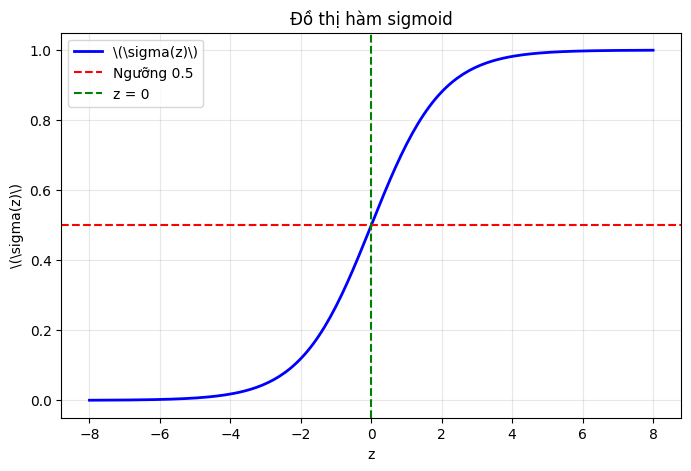

In [17]:
#bài 2
import numpy as np
import matplotlib.pyplot as plt
import os

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# z chạy từ -8 tới 8
z = np.linspace(-8, 8, 200)
y = sigmoid(z)

plt.figure(figsize=(8, 5))
plt.plot(z, y, label="\(\sigma(z)\)", color="blue", linewidth=2)

# Vẽ đường ngang tại 0.5 và đường dọc tại z = 0
plt.axhline(y=0.5, color='red', linestyle='--', label="Ngưỡng 0.5")
plt.axvline(x=0, color='green', linestyle='--', label="z = 0")

plt.title("Đồ thị hàm sigmoid")
plt.xlabel("z")
plt.ylabel("\(\sigma(z)\)")
plt.legend()
plt.grid(True, alpha=0.3)

In [11]:

#bài 3
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression().fit(X, y)
w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

def du_doan(gio):
    z = w * gio + b
    xac_suat = 1 / (1 + np.exp(-z))
    nhan = 1 if xac_suat >= 0.5 else 0
    print(f" Gio on: {gio:5.2f} | z = {z:6.4f} | Xac suat = {xac_suat:.4f} | Nhan = {nhan}")

print("Du doan cho cac ban cu the:")
for gio in [3.0, 8.0, 12.89, 18.0, 26.0]:
    du_doan(gio)

print("\nGiai thich cho truong hop 12.89 gio:")
print("Vi 12.89 gio la moc ma w*x + b = 0. Khi z = 0, e^0 = 1, mau so cua ham sigmoid")
print("bang 2, do do xac suat tinh ra bang dung 1/2 (tuc 0.5).")

Du doan cho cac ban cu the:
 Gio on:  3.00 | z = -3.8864 | Xac suat = 0.0201 | Nhan = 0
 Gio on:  8.00 | z = -1.9223 | Xac suat = 0.1276 | Nhan = 0
 Gio on: 12.89 | z = -0.0015 | Xac suat = 0.4996 | Nhan = 0
 Gio on: 18.00 | z = 2.0059 | Xac suat = 0.8814 | Nhan = 1
 Gio on: 26.00 | z = 5.1484 | Xac suat = 0.9942 | Nhan = 1

Giai thich cho truong hop 12.89 gio:
Vi 12.89 gio la moc ma w*x + b = 0. Khi z = 0, e^0 = 1, mau so cua ham sigmoid
bang 2, do do xac suat tinh ra bang dung 1/2 (tuc 0.5).


In [12]:
#bài 4
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("Ma tran nham lan")
print(f" TN = {tn:2d} (doan rot, that su rot)")
print(f" FP = {fp:2d} (doan qua, that ra rot)")
print(f" FN = {fn:2d} (doan rot, that ra qua)")
print(f" TP = {tp:2d} (doan qua, that su qua)\n")

# Tự tính bằng công thức
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print("Tu tinh cac thuoc do:")
print(f" Accuracy  = {accuracy:.4f}")
print(f" Precision = {precision:.4f}")
print(f" Recall    = {recall:.4f}")
print(f" F1        = {f1:.4f}")

Ma tran nham lan
 TN =  9 (doan rot, that su rot)
 FP =  3 (doan qua, that ra rot)
 FN =  1 (doan rot, that ra qua)
 TP = 17 (doan qua, that su qua)

Tu tinh cac thuoc do:
 Accuracy  = 0.8667
 Precision = 0.8500
 Recall    = 0.9444
 F1        = 0.8947


In [13]:
#bài 5
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
p = mo_hinh.predict_proba(X_test)[:, 1]

best_f1 = -1
best_nguong = -1

print("Nguong   F1_score")
for nguong in np.arange(0.05, 1.0, 0.05):
    y_pred = (p >= nguong).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f"{nguong:.2f}     {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_nguong = nguong

print(f"\nNguong cho F1 cao nhat la: {best_nguong:.2f}")
print("\nNhan xet: Nguong tot nhat theo F1 khong nhat thiet phai la 0.5. No phu thuoc")
print("vao muc do lech cua du lieu giua hai lop va cach mo hinh phan bo xac suat.")

Nguong   F1_score
0.05     0.7826
0.10     0.8182
0.15     0.8182
0.20     0.8571
0.25     0.9000
0.30     0.8947
0.35     0.8947
0.40     0.8947
0.45     0.8947
0.50     0.8947
0.55     0.8889
0.60     0.9412
0.65     0.9412
0.70     0.9091
0.75     0.8750
0.80     0.8387
0.85     0.8000
0.90     0.5600
0.95     0.4348

Nguong cho F1 cao nhat la: 0.60

Nhan xet: Nguong tot nhat theo F1 khong nhat thiet phai la 0.5. No phu thuoc
vao muc do lech cua du lieu giua hai lop va cach mo hinh phan bo xac suat.


In [14]:
# bài 6
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

pre_0 = precision_score(y_test, y_pred, pos_label=0)
rec_0 = recall_score(y_test, y_pred, pos_label=0)

print(f"Cham diem cho lop rot mon (pos_label=0):")
print(f" Precision = {pre_0:.4f}")
print(f" Recall    = {rec_0:.4f}\n")

print("Giai thich nguyen nhan khac biet:")
print("Khi doi lop duong (positive) tu qua mon (1) sang rot mon (0), y nghia cua")
print("TP, FP, TN, FN thay doi hoan toan. TP bay gio la so ban doan rot va that su rot")
print("(von la TN cua lop 1). FN bay gio la doan qua nhung that ra rot (von la FP cua lop 1).")
print("Vi tu so va mau so trong cong thuc hoan doi cho cho nhau, ket qua Precision")
print("va Recall se khac, du mo hinh va du lieu ban dau giu nguyen.")

Cham diem cho lop rot mon (pos_label=0):
 Precision = 0.9000
 Recall    = 0.7500

Giai thich nguyen nhan khac biet:
Khi doi lop duong (positive) tu qua mon (1) sang rot mon (0), y nghia cua
TP, FP, TN, FN thay doi hoan toan. TP bay gio la so ban doan rot va that su rot
(von la TN cua lop 1). FN bay gio la doan qua nhung that ra rot (von la FP cua lop 1).
Vi tu so va mau so trong cong thuc hoan doi cho cho nhau, ket qua Precision
va Recall se khac, du mo hinh va du lieu ban dau giu nguyen.
